> 

# Materials

Could you please provide more details or specify what you would like to know or do regarding "Alternative Fall Break: Halie & Co\."?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CharmsPendantsClasps = pd.read_csv('/work/CharmsPendantsClasps.csv', encoding = 'latin-1')
cabochonlist = pd.read_csv('/work/MaterialCabochon.csv', encoding = 'latin-1')
materialexpense = pd.read_csv('/work/MaterialExpense.csv', encoding = 'latin-1')

# Charms, Pendants, & Clasps (Material List)

In [3]:
CharmsPendantsClasps.describe()

,W/S Markup,W/S Price,W/S Rounded Price,Retail Markup,Retail Pricing w/ Markup,Shipping,Retail Price,Retail Rounded Price,Retail Profit,Proposed Pricing,Current Website Pricing,Assumes 1 free reweld; 2 jump rings at highest bulk pricing,Rio
count,414.0,412.000000,414.000000,414.0,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,12.000000,12.000000
mean,1.0,9.504854,10.603865,2.5,26.509662,0.016087,26.524155,27.053140,17.557971,26.980676,28.135266,2.839167,704137.666667
std,0.0,12.979395,12.846367,0.0,32.115917,0.231171,32.253583,32.239601,19.358233,32.227244,18.391915,2.491274,105306.719989
min,1.0,0.000000,0.000000,2.5,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,4.000000,0.140000,630159.000000
25%,1.0,3.000000,4.000000,2.5,10.000000,0.000000,10.000000,10.000000,7.000000,10.000000,25.000000,0.280000,649708.000000
50%,1.0,9.000000,10.000000,2.5,25.000000,0.000000,25.000000,26.000000,17.000000,26.000000,25.000000,2.970000,650411.000000
75%,1.0,12.000000,14.000000,2.5,35.000000,0.000000,35.000000,36.000000,22.000000,30.000000,25.000000,3.800000,693921.250000
max,1.0,180.000000,180.000000,2.5,450.000000,3.330000,453.000000,454.000000,274.000000,454.000000,186.000000,7.860000,924866.000000


In [4]:
CharmsPendantsClasps.nunique()

Item #                                                         197
Type                                                           115
Inventory Name                                                 221
Variant                                                         53
Metal                                                           10
Cost / Charm                                                   236
Labor                                                            7
Jump Ring                                                        3
Total Cost                                                     258
W/S Markup                                                       1
W/S Price                                                       36
W/S Rounded Price                                               25
Retail Markup                                                    1
Retail Pricing w/ Markup                                        25
Shipping                                                      

# Cabochon (Material List)

In [5]:
cabochonlist.shape

(533, 11)

In [6]:
print(cabochonlist['Mine'].unique())

[nan 'Kingman Mine' 'Lightening Ridge' '36']


In [7]:
cabochonlist.head()

,Mine,Item #,Stone Name,Current Qty,Size/ Gage,Shape,Color,Cost,Quantity/PKG,#VALUE!,Unnamed: 10
0,NaN,NaN,Natural Lone Mountain Turquoise,7,varied,oval,blue,33,7.0,4.714285714,NaN
1,NaN,NaN,Paloma Variscite,10,varied,oval,green,48,10.0,4.8,NaN
2,NaN,NaN,Spiny Oyster,30,varied,square,pink,80.5,30.0,2.683333333,NaN
3,NaN,NaN,Turquoise Mix,33,varied,oval,blue,148.75,33.0,4.507575758,NaN
4,NaN,243581,Aurora Opal Cabochon,1,6 x3.6mm,Diamond,Orange,6.78,1.0,6.78,NaN


In [8]:
# Check the columns of cabochonlist to identify the correct names
# print(cabochonlist.columns)

# Drop Irrelevant Columns
drop_columns = ['Mine', 'Item #', 'Unnamed: 10']
cabochonlist = cabochonlist.drop(columns=drop_columns)

# Rename #VALUE! to 'Unit Price'
cabochonlist = cabochonlist.rename(columns={'#VALUE!': 'Unit Price'})

# Rename 'Cost' to 'Total Price'
cabochonlist = cabochonlist.rename(columns={'Cost': 'Total Price'})

# Display the first few rows to verify changes
cabochonlist.head()
cabochonlist.shape

(533, 8)

In [9]:
cabochonlist.isna().sum()
# cabochonlist.shape

# Check which rows have a NaN for Stone Name
nothing_rows = cabochonlist[cabochonlist['Stone Name'].isna()]

# # Drop 'nothing_rows'
cabochonlist = cabochonlist.drop(nothing_rows.index)
cabochonlist.columns

Index(['Stone Name', 'Current Qty', 'Size/ Gage', 'Shape', 'Color',
       'Total Price', 'Quantity/PKG', 'Unit Price'],
      dtype='object')

In [10]:
cabochonlist.shape

(519, 8)

In [11]:
cabochonlist.dtypes

Stone Name       object
Current Qty      object
Size/ Gage       object
Shape            object
Color            object
Total Price      object
Quantity/PKG    float64
Unit Price       object
dtype: object

In [12]:
cabochonlist['Size/ Gage'].unique()

array(['varied', '6 x3.6mm', '10 x 8 x 3.6 mm', '10 x 8x 3.4 mm',
       '11 x 8 x 3.6 mm', '12 x 11 x 4.1 mm', '13 x 8 x 3.2 mm',
       '19 x 11 x 3.8 mm', '6.3 mm', '9 x 6x 3.6 mm', 'Med', '8mm', '9mm',
       '8 x 10', '10 x 14', '15 x20', nan, '10mm', '6 x 10', '12 x 10mm',
       '10 x 8mm', '18x13mm', '12mm', '18 x 13mm', '30x 22mm', '4mm',
       '14 x 10mm', '14 x 10mm ', '16 x 12mm', '25 x 18mm', '8mm ', '5mm',
       '6mm', '6x4', '18 x 13mm ', '10mm ', '5-6mm', '18 x 13 mm',
       '10 mm ', '12mm ', '16mm ', '25 x 18 mm', '25 x 8mm', '22 x 8 mm',
       '15mm', '6mm ', '8 mm ', '18 X 13', '8 X 6', '8MM', '6MM',
       '12 X 10', '14 X 10', '4 MM', 'Mixed', '5MM', '4MM', '10', '18x13',
       '6MM ', '22x6mm', '12.15 x 9.95', '12.32 x 9.97', '12.80MM',
       '8.25 x 6.13', '9.27 x 7.34', '24.86 x 21.67', 'Large', 'Small',
       'small', 'X-Large', 'X-Small', '14.55 x 14.85', '18.23 x15.14',
       '24.71 x 15.70', '15.27 x 12.25', '21.26 x 14.50', '17.48MM ',
       '14x1

In [13]:
# Identify identical entries (capital & lowercase letters)
cabochonlist['Size/ Gage'].str.lower().value_counts()

# Convert all entries to lowercase
cabochonlist['Size/ Gage'] = cabochonlist['Size/ Gage'].str.lower()

cabochonlist['Size/ Gage'].nunique()

104

In [14]:

# for value in cabochonlist['Size/ Gage'].unique():
#     print(cabochonlist['Size/ Gage'][cabochonlist['Size/ Gage'] == value].value_counts())

cabochonlist['Size/ Gage'].unique()

# Print every row of: quantities of each unique value in the 'Size/ Gage' colum in descending order

display(cabochonlist['Size/ Gage'].value_counts().sort_values(ascending=False).reset_index().head(40))

# display(cabochonlist['Size/ Gage'].value_counts().sort_values(ascending=False))


# for value in cabochonlist['Size/ Gage'].unique():
#     print(f"{value}: {cabochonlist['Size/ Gage'][cabochonlist['Size/ Gage'] == value].count()}")

,Size/ Gage,count
0,6mm,37
1,varied,33
2,8mm,31
3,12mm,19
4,4mm,18
5,18 x 13,18
6,18 x 13mm,16
7,12 x 10mm,15
8,various,15
9,5mm,11


In [15]:
# Remove all spaces within values in Size/ Gage
cabochonlist['Size/ Gage'] = cabochonlist['Size/ Gage'].str.replace(' ', '')

cabochonlist['Size/ Gage'].unique()

array(['varied', '6x3.6mm', '10x8x3.6mm', '10x8x3.4mm', '11x8x3.6mm',
       '12x11x4.1mm', '13x8x3.2mm', '19x11x3.8mm', '6.3mm', '9x6x3.6mm',
       'med', '8mm', '9mm', '8x10', '10x14', '15x20', nan, '10mm', '6x10',
       '12x10mm', '10x8mm', '18x13mm', '12mm', '30x22mm', '4mm',
       '14x10mm', '16x12mm', '25x18mm', '5mm', '6mm', '6x4', '5-6mm',
       '16mm', '25x8mm', '22x8mm', '15mm', '18x13', '8x6', '12x10',
       '14x10', 'mixed', '10', '22x6mm', '12.15x9.95', '12.32x9.97',
       '12.80mm', '8.25x6.13', '9.27x7.34', '24.86x21.67', 'large',
       'small', 'x-large', 'x-small', '14.55x14.85', '18.23x15.14',
       '24.71x15.70', '15.27x12.25', '21.26x14.50', '17.48mm', '17.26mm',
       '15.44mm', '1', '10.59x8.59', '15.20x15.20', '17.15x11.48',
       '18.29x13.75', '14mm', '14~14.5x10~10.5x4~5mm', '8x3.5mm',
       '10x4~5mm', '8x6x3mm', '6x4x2.5-3mm', '6x4x2~3mm', '8x6x4.5mm',
       '6mmx4mm', '3mm', '8x13', '10x8', '5x7mm', '5x7', '8x16mm',
       'various', 'varius', '

In [16]:
# Rename 'various' and 'varius' to 'varied'
cabochonlist['Size/ Gage'] = cabochonlist['Size/ Gage'].replace(['various', 'varius'], 'varied')

cabochonlist['Size/ Gage'].unique()

array(['varied', '6x3.6mm', '10x8x3.6mm', '10x8x3.4mm', '11x8x3.6mm',
       '12x11x4.1mm', '13x8x3.2mm', '19x11x3.8mm', '6.3mm', '9x6x3.6mm',
       'med', '8mm', '9mm', '8x10', '10x14', '15x20', nan, '10mm', '6x10',
       '12x10mm', '10x8mm', '18x13mm', '12mm', '30x22mm', '4mm',
       '14x10mm', '16x12mm', '25x18mm', '5mm', '6mm', '6x4', '5-6mm',
       '16mm', '25x8mm', '22x8mm', '15mm', '18x13', '8x6', '12x10',
       '14x10', 'mixed', '10', '22x6mm', '12.15x9.95', '12.32x9.97',
       '12.80mm', '8.25x6.13', '9.27x7.34', '24.86x21.67', 'large',
       'small', 'x-large', 'x-small', '14.55x14.85', '18.23x15.14',
       '24.71x15.70', '15.27x12.25', '21.26x14.50', '17.48mm', '17.26mm',
       '15.44mm', '1', '10.59x8.59', '15.20x15.20', '17.15x11.48',
       '18.29x13.75', '14mm', '14~14.5x10~10.5x4~5mm', '8x3.5mm',
       '10x4~5mm', '8x6x3mm', '6x4x2.5-3mm', '6x4x2~3mm', '8x6x4.5mm',
       '6mmx4mm', '3mm', '8x13', '10x8', '5x7mm', '5x7', '8x16mm',
       '13.46x9.78'], dtype=o

In [17]:
# Remove all 'mm' from 
cabochonlist['Size/ Gage'] = cabochonlist['Size/ Gage'].str.replace('mm', '')

cabochonlist['Size/ Gage'].unique()

array(['varied', '6x3.6', '10x8x3.6', '10x8x3.4', '11x8x3.6', '12x11x4.1',
       '13x8x3.2', '19x11x3.8', '6.3', '9x6x3.6', 'med', '8', '9', '8x10',
       '10x14', '15x20', nan, '10', '6x10', '12x10', '10x8', '18x13',
       '12', '30x22', '4', '14x10', '16x12', '25x18', '5', '6', '6x4',
       '5-6', '16', '25x8', '22x8', '15', '8x6', 'mixed', '22x6',
       '12.15x9.95', '12.32x9.97', '12.80', '8.25x6.13', '9.27x7.34',
       '24.86x21.67', 'large', 'small', 'x-large', 'x-small',
       '14.55x14.85', '18.23x15.14', '24.71x15.70', '15.27x12.25',
       '21.26x14.50', '17.48', '17.26', '15.44', '1', '10.59x8.59',
       '15.20x15.20', '17.15x11.48', '18.29x13.75', '14',
       '14~14.5x10~10.5x4~5', '8x3.5', '10x4~5', '8x6x3', '6x4x2.5-3',
       '6x4x2~3', '8x6x4.5', '3', '8x13', '5x7', '8x16', '13.46x9.78'],
      dtype=object)

In [18]:
# Replace all "Nan" with "0" in 'Current Quantity'
cabochonlist['Current Qty'] = cabochonlist['Current Qty'].replace('Nan', '0')
cabochonlist['Current Qty'] = cabochonlist['Current Qty'].replace(' nan', '0')
cabochonlist['Current Qty'] = cabochonlist['Current Qty'].replace(' ', '0')
cabochonlist['Current Qty'] = cabochonlist['Current Qty'].fillna('0')
cabochonlist['Current Qty'] = cabochonlist['Current Qty'].replace('ghgg', '0')


# Convert 'Current Qty' to integer
cabochonlist['Current Qty'] = cabochonlist['Current Qty'].astype(int)
cabochonlist['Current Qty'].unique()


array([  7,  10,  30,  33,   1,   5,   0,   2,  12,   6,   8, 250,   4,
         3,  16,  18,  40,  20,  24,  13,   9, 100,  25,  14,  15,  45,
        47,  50,  17,  11,  32,  35,  21,  26,  23,  31,  80,  81,  51,
        44,  19,  43,  66,  36,  22])

In [19]:
# Convert columns to correct types


# Convert all to lowercase
cabochonlist['Shape'] = cabochonlist['Shape'].str.lower()

# Strip spaces from 'Shape'
cabochonlist['Shape'] = cabochonlist['Shape'].str.strip()

# Rename 'oear' to 'pear'
cabochonlist['Shape'] = cabochonlist['Shape'].replace('oear', 'pear')

# Rename 'irreg' to 'irregular'
cabochonlist['Shape'] = cabochonlist['Shape'].replace('irreg', 'irregular')

# Rename 'various' to 'varied'
cabochonlist['Shape'] = cabochonlist['Shape'].replace('various', 'varied')

# Fill empty cells with nan
cabochonlist['Shape'] = cabochonlist['Shape'].replace('', np.nan)
cabochonlist['Shape'].unique()

array(['oval', 'square', 'diamond', 'rectangle', 'round', nan, 'mixed',
       'teardop', 'pear', 'oblong', 'irregular', 'trillion', 'baquette',
       'tappered baguette', 'triangle', 'half moon', 'trapezoid',
       'marquise', 'odd', 'pearl', 'teardrop', 'pill shape', 'varied'],
      dtype=object)

In [20]:

# Convert all to lowercase
cabochonlist['Color'] = cabochonlist['Color'].str.lower()

# Replace ''lt blue ' with 'light blue'
cabochonlist['Color'] = cabochonlist['Color'].replace('lt blue ', 'light blue')
cabochonlist['Color'].unique()


array(['blue', 'green', 'pink', 'orange', 'multi-color',
       'green, red, blue, purple', 'yellow,white,', 'black onyx pearl',
       'black onyx white mother of pearl', 'lapis mother of perl',
       'lapis malachite', 'lapis pearl', 'lapis coral jasper', 'red',
       'white', 'green ', 'green, white, brown', 'brown', nan, 'multi',
       'brown/red', 'yellow', 'yellow/gold', 'brown ', 'black',
       'reddish/brown', 'silver', 'white/black', 'black/white', 'blue ',
       'white/green', 'dark sparkle', 'black/multi',
       'honey, mauve and black', 'black spotted',
       'blue, light blue, green, light green, pink', 'marble', 'mixed',
       'peach', 'light blue', 'cream luster', 'blue/white/dark blue',
       'turq', 'opal', 'turquoise bay', 'light sapphire blue', 'teal',
       'royal blue', 'autum green', 'pacific blue', 'light sapphire',
       'olive green', 'shamrock dark green', 'peridot light green',
       'olive', 'shamrock', 'light aqua', 'orange/red/yellow', 'purple'

In [21]:
# Reformat 'Total Price' to remove $ & convert to float
cabochonlist['Total Price'] = cabochonlist['Total Price'].str.replace('$', '')
cabochonlist['Total Price'] = cabochonlist['Total Price'].astype(float)

# Replace '#DIV/0!' with 0
# Reformat 'Unit Price' to remove $ & convert to float
cabochonlist['Unit Price'] = cabochonlist['Unit Price'].replace('#DIV/0!', 0)
cabochonlist['Unit Price'] = cabochonlist['Unit Price'].str.replace('$', '')
cabochonlist['Unit Price'] = cabochonlist['Unit Price'].astype(float)

# Keep only first 5 decimal places
cabochonlist['Unit Price'] = cabochonlist['Unit Price'].round(5)

cabochonlist['Unit Price'].unique()

array([4.71429e+00, 4.80000e+00, 2.68333e+00, 4.50758e+00, 6.78000e+00,
       7.78000e+00, 9.78000e+00, 5.16000e+00, 5.55000e+00, 3.30000e+00,
       4.50000e+00, 4.30000e+00, 4.10000e+00, 3.48000e+00, 2.18000e+00,
       6.60000e+00, 6.25000e+00, 4.35000e+00, 4.15000e+00, 6.50000e-01,
       4.04170e-01, 4.66670e-01, 3.17500e+00, 8.00000e-03, 3.60500e+00,
       3.38000e+00, 3.23750e+00, 8.11500e+00, 5.63667e+00, 1.70000e-01,
       2.90000e-01, 5.20160e+00, 1.89333e+00, 1.94500e+00, 1.74125e+00,
       1.75833e+00, 2.09125e+00, 2.17625e+00, 2.88833e+00, 4.53250e+00,
       7.98500e+00, 1.32333e+00, 1.20000e-01, 2.50000e-01, 2.70000e-01,
       3.40000e-01, 3.70000e-01, 4.20000e-01, 1.24625e+00, 1.61875e+00,
       1.69000e+00, 3.05000e+00, 4.20000e+00, 5.56110e-01, 1.25500e+00,
       1.12025e+00, 1.25050e+00, 1.66833e+00, 5.02780e-01, 2.56611e+00,
       2.60667e+00, 5.15420e-01, 5.26110e-01, 3.79000e-01, 5.66670e-01,
       5.64440e-01, 7.18000e-01, 7.73120e-01, 1.90000e-01, 3.300

In [22]:
cabochonlist.describe()

,Current Qty,Total Price,Quantity/PKG,Unit Price
count,519.000000,511.000000,459.000000,459.000000
mean,7.730250,22.256092,10.649237,5.804329
std,16.656201,29.344177,17.041212,7.597988
min,0.000000,0.960000,1.000000,0.000000
25%,1.000000,6.080000,1.000000,0.993750
50%,2.000000,13.000000,6.000000,2.880000
75%,9.000000,25.900000,14.000000,8.000000
max,250.000000,376.000000,250.000000,75.000000


In [23]:
# Convert all Stone Name to lowercase
cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.lower()

In [24]:
cabochonlist.dtypes

Stone Name       object
Current Qty       int64
Size/ Gage       object
Shape            object
Color            object
Total Price     float64
Quantity/PKG    float64
Unit Price      float64
dtype: object

In [25]:
cabochonlist['Stone Name'].value_counts().sort_values(ascending=False).reset_index()

,Stone Name,count
0,frosted glass,15
1,labradorite,13
2,chrysocolla,10
3,blue lace agare,9
4,australian bolder opal,8
...,...,...
372,moonston aa,1
373,rose quartz,1
374,sleeping beatuy turq,1
375,"sterling opal, nova",1


In [26]:
# Capture the first two (...) groups into two columns
cabochonlist[['Stone Type 1', 'Stone Type 2']] = cabochonlist['Stone Name'].str.extract(
    r'\(([^()]*)\).*?\(([^()]*)\)'
)
# Remove all (...) from Stone Name
cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.replace(r'\([^)]*\)', '', regex=True).str.strip()


# # Strip spaces
# cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.strip()

# # Copy ( ) individually for each item and copy into a new column, 'Stone Type'
# cabochonlist['Stone Type'] = cabochonlist['Stone Name'].str.extract(r'\(([^)]+)\)')
# cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.strip()

# # Remove first ( ) item from Stone Name
# cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.replace(r'\([^)]*\)', '', regex=True)
# cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.strip()

# Remove 'cabochon, ' from 'Stone Name' if present
cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.replace('cabochon, ', '', regex=False)
cabochonlist['Stone Name'] = cabochonlist['Stone Name'].str.strip()



In [27]:
cabo_copy = cabochonlist.copy()

# If ',' is present, extract everything before it; otherwise, keep the entire string
cabo_copy['Stone'] = cabochonlist['Stone Name'].str.split(',').str[0]

cabo_copy['Stone'].unique()

array(['natural lone mountain turquoise', 'paloma variscite',
       'spiny oyster', 'turquoise mix', 'aurora opal cabochon',
       'oregon surfite cabachon', 'checkerboard gemstone',
       'inlay mosaic ',
       'inlay multi gemstone black onyx white mother of pearl',
       'inlay mosaic gemstone',
       'inlay mosaic striped natural black onyx white mother of pearl',
       'inlay natual lapis pearl', 'inlay natuaral multi gemstone',
       'inlay natural lapis pearl  checkerboard square cabochon southwestern',
       'inlay natural lapis pearl intarsia multi gemstone',
       'inlay striped natural ',
       'intarsia multi gemstone inlay. natural lapis coral jasper',
       'leopardskin jasper ', 'rhodonite ', 'white howlite ',
       'african "jade" 1pkg2', 'bead mix', 'african "jade"  ',
       'autumn hickoryite ', 'bamboo coral ', 'blue apatite ',
       'blue lace agate ', 'botswana agate ', 'carnelian ',
       "cat's eye glass ", 'chrysanthemum stone ', 'chrysocolla ',


In [28]:
# If 'mm' is present, remove all numbers and 'mm'
cabo_copy['Stone'] = cabo_copy['Stone'].str.replace(r'\d+mm', '', regex=True)
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()
cabo_copy['Stone'].unique()

array(['natural lone mountain turquoise', 'paloma variscite',
       'spiny oyster', 'turquoise mix', 'aurora opal cabochon',
       'oregon surfite cabachon', 'checkerboard gemstone', 'inlay mosaic',
       'inlay multi gemstone black onyx white mother of pearl',
       'inlay mosaic gemstone',
       'inlay mosaic striped natural black onyx white mother of pearl',
       'inlay natual lapis pearl', 'inlay natuaral multi gemstone',
       'inlay natural lapis pearl  checkerboard square cabochon southwestern',
       'inlay natural lapis pearl intarsia multi gemstone',
       'inlay striped natural',
       'intarsia multi gemstone inlay. natural lapis coral jasper',
       'leopardskin jasper', 'rhodonite', 'white howlite',
       'african "jade" 1pkg2', 'bead mix', 'african "jade"',
       'autumn hickoryite', 'bamboo coral', 'blue apatite',
       'blue lace agate', 'botswana agate', 'carnelian',
       "cat's eye glass", 'chrysanthemum stone', 'chrysocolla', 'citrine',
       'craz

In [29]:
cabo_copy.head()

,Stone Name,Current Qty,Size/ Gage,Shape,Color,Total Price,Quantity/PKG,Unit Price,Stone Type 1,Stone Type 2,Stone
0,natural lone mountain turquoise,7,varied,oval,blue,33.00,7.0,4.71429,NaN,NaN,natural lone mountain turquoise
1,paloma variscite,10,varied,oval,green,48.00,10.0,4.80000,NaN,NaN,paloma variscite
2,spiny oyster,30,varied,square,pink,80.50,30.0,2.68333,NaN,NaN,spiny oyster
3,turquoise mix,33,varied,oval,blue,148.75,33.0,4.50758,NaN,NaN,turquoise mix
4,aurora opal cabochon,1,6x3.6,diamond,orange,6.78,1.0,6.78000,NaN,NaN,aurora opal cabochon


In [30]:
cabochonlist['Stone Name'].unique()


array(['natural lone mountain turquoise', 'paloma variscite',
       'spiny oyster', 'turquoise mix', 'aurora opal cabochon',
       'oregon surfite cabachon',
       'checkerboard gemstone, natural black onyx pearl square cabochon- medium square',
       'inlay mosaic , striped black onyx pearl cabochon,',
       'inlay multi gemstone black onyx white mother of pearl',
       'inlay mosaic gemstone, natural black onyx mother of pearl',
       'inlay mosaic striped natural black onyx white mother of pearl',
       'inlay natual lapis pearl, mosaic intarsia mother of pearl lapis',
       'inlay natuaral multi gemstone, lapis malachite oval',
       'inlay natural lapis pearl  checkerboard square cabochon southwestern, 1 gemstone',
       'inlay natural lapis pearl intarsia multi gemstone',
       'inlay striped natural , black onyx white mother of pearl',
       'intarsia multi gemstone inlay. natural lapis coral jasper',
       'leopardskin jasper , 12x10mm calibrated oval, b grade, mo

In [31]:
# If ' - ' is present, remove all characters after it
cabo_copy['Stone'] = cabo_copy['Stone'].str.split(' - ').str[0]
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()
cabo_copy['Stone'].unique()


array(['natural lone mountain turquoise', 'paloma variscite',
       'spiny oyster', 'turquoise mix', 'aurora opal cabochon',
       'oregon surfite cabachon', 'checkerboard gemstone', 'inlay mosaic',
       'inlay multi gemstone black onyx white mother of pearl',
       'inlay mosaic gemstone',
       'inlay mosaic striped natural black onyx white mother of pearl',
       'inlay natual lapis pearl', 'inlay natuaral multi gemstone',
       'inlay natural lapis pearl  checkerboard square cabochon southwestern',
       'inlay natural lapis pearl intarsia multi gemstone',
       'inlay striped natural',
       'intarsia multi gemstone inlay. natural lapis coral jasper',
       'leopardskin jasper', 'rhodonite', 'white howlite',
       'african "jade" 1pkg2', 'bead mix', 'african "jade"',
       'autumn hickoryite', 'bamboo coral', 'blue apatite',
       'blue lace agate', 'botswana agate', 'carnelian',
       "cat's eye glass", 'chrysanthemum stone', 'chrysocolla', 'citrine',
       'craz

In [32]:
# If '# x' or '# mm', remove all characters after it
cabo_copy['Stone'] = cabo_copy['Stone'].str.split(r'\d+ x').str[0]
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()

cabo_copy['Stone'] = cabo_copy['Stone'].str.split(r'\d+mm').str[0]
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()

# '#x', remove x and all characters after it
cabo_copy['Stone'] = cabo_copy['Stone'].str.split(r'\d+x').str[0]
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()

# if '#-', remove - and all characters after it
cabo_copy['Stone'] = cabo_copy['Stone'].str.split(r'\d+-').str[0]
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()

# Replace all '' with NaN
cabo_copy['Stone'] = cabo_copy['Stone'].replace('', np.nan)


# Remove all 'mm', '1pkg2', 'pk/1', and '  10 mm' from 'Stone'
cabo_copy['Stone'] = cabo_copy['Stone'].str.replace('1pkg2', '')
cabo_copy['Stone'] = cabo_copy['Stone'].str.replace('pk/1', '')
cabo_copy['Stone'] = cabo_copy['Stone'].str.replace('mm', '')
cabo_copy['Stone'] = cabo_copy['Stone'].str.replace('  10 mm', '')
cabo_copy['Stone'] = cabo_copy['Stone'].str.strip()

cabo_copy['Stone'].unique()

array(['natural lone mountain turquoise', 'paloma variscite',
       'spiny oyster', 'turquoise mix', 'aurora opal cabochon',
       'oregon surfite cabachon', 'checkerboard gemstone', 'inlay mosaic',
       'inlay multi gemstone black onyx white mother of pearl',
       'inlay mosaic gemstone',
       'inlay mosaic striped natural black onyx white mother of pearl',
       'inlay natual lapis pearl', 'inlay natuaral multi gemstone',
       'inlay natural lapis pearl  checkerboard square cabochon southwestern',
       'inlay natural lapis pearl intarsia multi gemstone',
       'inlay striped natural',
       'intarsia multi gemstone inlay. natural lapis coral jasper',
       'leopardskin jasper', 'rhodonite', 'white howlite',
       'african "jade"', 'bead mix', 'autumn hickoryite', 'bamboo coral',
       'blue apatite', 'blue lace agate', 'botswana agate', 'carnelian',
       "cat's eye glass", 'chrysanthemum stone', 'chrysocolla', 'citrine',
       'crazy lace agate', 'denim lapis', '

In [33]:
cabochonlist['New Stone Name'] = cabo_copy['Stone']

# Move column so ['New Stone Name'] is in the 2nd column
cabochonlist = cabochonlist[['Stone Name', 'New Stone Name', 'Stone Type 1', 'Stone Type 2', 'Size/Gage', 'Shape', 'Color', 'Total Price', 'Quantity/PKG', 'Unit Price', 'Current Qty']]

# Rename 'Size/ Gage' to 'Size/Gage'
# cabochonlist = cabochonlist.rename(columns={'Size/ Gage': 'Size/Gage'})

cabochonlist.head()

# Export Cleaned Data to CSV
cabochonlist.to_csv('cleancabochon.csv', index=False)

KeyError: "['Size/Gage'] not in index"

In [28]:
cabochonlist['Stone Type 1'].unique()

array([nan, 'fiber optic glass', 'quartz'], dtype=object)

In [29]:
cabochonlist['Stone Type 2'].unique()

array([nan, '5', 'natural'], dtype=object)

In [30]:
# # Remove all 'mm', 'x', and spaces from 'Size/ Gage'
# import re

# def normalize_size(text):
#     if pd.isna(text):
#         return text
#     # lowercase, remove 'mm', normalize 'x' spacing, strip extra spaces
#     text = re.sub(r'\d*mm.', '', text)     
#     text = re.sub(r'\d*[x×].*', 'x', text)     
#     text = re.sub(r'\s+', ' ', text).strip() 
#     return text

# # cabochonlist['Size/ Gage'] = cabochonlist['Size/ Gage'].apply(normalize_size)
# cabochonlist['Stone Name'] = cabochonlist['Stone Name'].apply(normalize_size)

# #Rename 'Size/ Gage' to 'Size/Gage'
# # cabochonlist = cabochonlist.rename(columns={'Size/ Gage': 'Size/Gage'})

# cabochonlist['Stone Name'].unique()

In [31]:
# Compare dimensions (#x#) in 'Stone Name' to 'Size/ Gage'; if the same, then remove from 'Stone Name'


In [50]:
cabochonlist.head(20)

,Stone Name,Current Qty,Size/ Gage,Shape,Color,Total Price,Quantity/PKG,Unit Price,Stone Type 1,Stone Type 2
0,natural lone mountain turquoise,7,varied,oval,blue,33.00,7.0,4.71429,NaN,NaN
1,paloma variscite,10,varied,oval,green,48.00,10.0,4.80000,NaN,NaN
2,spiny oyster,30,varied,square,pink,80.50,30.0,2.68333,NaN,NaN
3,turquoise mix,33,varied,oval,blue,148.75,33.0,4.50758,NaN,NaN
4,aurora opal cabochon,1,6x3.6,diamond,orange,6.78,1.0,6.78000,NaN,NaN
5,oregon surfite cabachon,1,10x8x3.6,rectangle,multi-color,7.78,1.0,7.78000,NaN,NaN
6,oregon surfite cabachon,1,10x8x3.4,rectangle,multi-color,7.78,1.0,7.78000,NaN,NaN
7,oregon surfite cabachon,1,11x8x3.6,rectangle,multi-color,7.78,1.0,7.78000,NaN,NaN
8,oregon surfite cabachon,1,12x11x4.1,rectangle,multi-color,9.78,1.0,9.78000,NaN,NaN
9,oregon surfite cabachon,1,13x8x3.2,diamond,"green, red, blue, purple",7.78,1.0,7.78000,NaN,NaN


In [33]:
cabochonlist.shape


(519, 10)

# Material Expense
1. Drop Empty Rows
2. Group by Month
3. Group by Count of Item Number
4. Sort by Count (descending)

In [34]:
materialexpense.shape

(2453, 18)

In [35]:
materialexpense.describe()

,Quantity Order,Unnamed: 15,Unnamed: 16,Unnamed: 17
count,2254.000000,53.000000,53.000000,53.000000
mean,11.583922,23.773585,-6.056604,23.773585
std,25.477044,2.171861,10.472336,2.171861
min,0.000000,20.000000,-26.000000,20.000000
25%,1.000000,25.000000,-18.000000,25.000000
50%,3.000000,25.000000,-3.000000,25.000000
75%,10.000000,25.000000,-3.000000,25.000000
max,300.000000,25.000000,11.000000,25.000000


In [36]:
c_materialexpense = materialexpense.dropna(how='all')
c_materialexpense.head()

,Date,OrderNumber,Total Order spend,ItemNumber,ItemDescription,Total Count,Quantity Order,Price/ Pkg,Quantity in PKG,Unit Price + SHIPPING,Unit,NOTES,Total Item Cost,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,4/28/2023,2869687586,$301,BU65CZ,Gold Filled (14KGF) 5.7 x 4.9mm Tiny Butterfly...,NaN,3.0,$5.00,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2023,2869687586,$301,ST76LETR2,Gold Filled (14KGF) 6 X 9mm Star Shape Letter ...,NaN,2.0,$2.78,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4/26/2023,2869687586,$301,AA01,Gold Filled (14KGF) 5.9mm Basic Letter Charm W...,NaN,1.0,$4.30,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4/25/2023,2869687586,$301,CZ84RD,Gold Filled (14KGF) 8.3 x 4.8mm Blank Disc wit...,NaN,3.0,$5.60,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4/24/2023,2869687586,$301,EY9335CZ,Gold Filled (14KGF) / 925 Silver 9.3 x 3.5mm E...,NaN,3.0,$4.28,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
import datetime

In [38]:
c_materialexpense['Month'] = pd.to_datetime(c_materialexpense['Date']).dt.month

# Download a list of the number of times that items appear in orders, grouped by months
# items_materialexpense = c_materialexpense.groupby('Month')['ItemNumber'].value_counts().reset_index()
items_materialexpense = c_materialexpense['ItemNumber'].value_counts().reset_index()
#items_materialexpense = items_materialexpense * c_materialexpense['Quantity Order']
#print(items_materialexpense)
#print(c_materialexpense['ItemNumber'].value_counts() * c_materialexpense['Quantity Order'])
#items_materialexpense.to_csv('item_count_by_month.csv', index=False)

# Get list of keys (item numbers)
unique_items = set(c_materialexpense['ItemNumber'])

# key value pairs where unique items is the list of keys
item_counts = dict.fromkeys(unique_items, 0.0)

# loop through and populate item counts
for i in c_materialexpense:
    # item_counts[i] += item['Quantity Order']

print(item_counts)

IndentationError: expected an indented block after 'for' statement on line 18 (2753433398.py, line 21)

JUMP RING 14KY 2.4MM ID 24GA

In [119]:
materialexpense.head()

,Date,OrderNumber,Total Order spend,ItemNumber,ItemDescription,Total Count,Quantity Order,Price/ Pkg,Quantity in PKG,Unit Price + SHIPPING,Unit,NOTES,Total Item Cost,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,4/28/2023,2869687586,$301,BU65CZ,Gold Filled (14KGF) 5.7 x 4.9mm Tiny Butterfly...,NaN,3.0,$5.00,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2023,2869687586,$301,ST76LETR2,Gold Filled (14KGF) 6 X 9mm Star Shape Letter ...,NaN,2.0,$2.78,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4/26/2023,2869687586,$301,AA01,Gold Filled (14KGF) 5.9mm Basic Letter Charm W...,NaN,1.0,$4.30,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4/25/2023,2869687586,$301,CZ84RD,Gold Filled (14KGF) 8.3 x 4.8mm Blank Disc wit...,NaN,3.0,$5.60,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4/24/2023,2869687586,$301,EY9335CZ,Gold Filled (14KGF) / 925 Silver 9.3 x 3.5mm E...,NaN,3.0,$4.28,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
# convert the date values and extract month
c_materialexpense['Date'] = (
    c_materialexpense['Date']
    .astype(str)
    .str.strip()
    .replace('', pd.NA)
)
c_materialexpense['Date'] = pd.to_datetime(
    c_materialexpense['Date'], errors='coerce'
    )
c_materialexpense['Month'] = c_materialexpense['Date'].dt.to_period('M')
c_materialexpense.head()

,Date,OrderNumber,Total Order spend,ItemNumber,ItemDescription,Total Count,Quantity Order,Price/ Pkg,Quantity in PKG,Unit Price + SHIPPING,Unit,NOTES,Total Item Cost,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Month
0,2023-04-28,2869687586,$301,BU65CZ,Gold Filled (14KGF) 5.7 x 4.9mm Tiny Butterfly...,NaN,3.0,$5.00,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-04
1,2023-04-27,2869687586,$301,ST76LETR2,Gold Filled (14KGF) 6 X 9mm Star Shape Letter ...,NaN,2.0,$2.78,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-04
2,2023-04-26,2869687586,$301,AA01,Gold Filled (14KGF) 5.9mm Basic Letter Charm W...,NaN,1.0,$4.30,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-04
3,2023-04-25,2869687586,$301,CZ84RD,Gold Filled (14KGF) 8.3 x 4.8mm Blank Disc wit...,NaN,3.0,$5.60,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-04
4,2023-04-24,2869687586,$301,EY9335CZ,Gold Filled (14KGF) / 925 Silver 9.3 x 3.5mm E...,NaN,3.0,$4.28,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-04


In [125]:
# clean the total order spend column and remove the $ sign
c_materialexpense['Total Order spend'] = (
    c_materialexpense['Total Order spend']
    .astype(str)
    .str.strip()
    .str.replace(r'[^0-9.\-]', '', regex=True)
)
c_materialexpense['Total Order spend'] = c_materialexpense['Total Order spend'].replace(['', 'nan', 'NaN', pd.NA], np.nan)
c_materialexpense['Total Order spend'] = c_materialexpense['Total Order spend'].astype(float)

In [128]:
monthly_summary = c_materialexpense.groupby('Month').agg(
    Item_Count=('ItemNumber', 'nunique'),  # count unique
    ItemNumbers=('ItemNumber', lambda x: ', '.join(x.dropna().astype(str).unique())),  # list item numbers
    ItemDescriptions=('ItemDescription', lambda x: ', '.join(x.dropna().unique())),  # list descriptions
    Total_Spend=('Total Order spend', 'sum') #sum
).reset_index()

monthly_summary = monthly_summary.sort_values(by='Item_Count', ascending=False)

print(monthly_summary)

      Month  Item_Count                                        ItemNumbers  \
39  2023-10         109  643750A, 677314, 924342, 670324, 670312, 67055...   
49  2024-08         102  10807F, 10791F, 10791AF, 115022, 330273, 10326...   
19  2022-02          94  H20-L5192CL, H20-L5522CL, H20-L5890CL, H20-L56...   
56  2025-03          91  924623, 640574, 634733, 633252, 600612, 100412...   
30  2023-01          87  CZ117HE, HA005CZ, H20-1624DG, H20-K3467CL, H20...   
..      ...         ...                                                ...   
3   2020-03           1                                       344-1125Main   
11  2021-03           1                                             618209   
8   2020-08           1                                             640828   
1   2017-12           1                                             618838   
44  2024-03           1                                             700519   

                                     ItemDescriptions  Total_Sp

In [131]:
c_materialexpense['Year'] = c_materialexpense['Date'].dt.year
c_materialexpense['Month'] = c_materialexpense['Date'].dt.month
monthly_item_summary = (
    c_materialexpense.groupby(['Year', 'Month', 'ItemNumber', 'ItemDescription'])
    .agg(Total_Spend=('Total Order spend', 'sum'))
    .reset_index()
    .sort_values(by=['Year', 'Month', 'Total_Spend'], ascending=[True, True, False])
)

print(monthly_item_summary)

        Year  Month                              ItemNumber  \
0     2016.0    4.0                                 632812B   
1     2017.0   12.0                                  618838   
2     2019.0   12.0                                  617291   
3     2019.0   12.0                                  692766   
4     2019.0   12.0                                  692767   
...      ...    ...                                     ...   
2261  2025.0   10.0                          20270:163842:P   
2280  2025.0   10.0  SHEET:36923:P - 1pcs X 2 INCH X 2 INCH   
2281  2025.0   10.0  SHEET:36924:P - 1pcs X 2 INCH X 2 INCH   
2282  2025.0   10.0                      SHIPPING ESTIMATES   
2262  2025.0   10.0                                  335119   

                                      ItemDescription  Total_Spend  
0                            SS Chain 5.9MM Cable FTG         0.00  
1     Sterling Silver Hinged One-Piece Cuff Link Back       416.00  
2                             COMP. 

In [134]:
# Filter rows for year 2025
data_2025 = c_materialexpense[c_materialexpense['Year'] == 2025]

# Group by Month and ItemNumber for 2025 only
monthly_item_summary_2025 = (
    data_2025.groupby(['Year', 'Month', 'ItemNumber', 'ItemDescription'])
    .agg(Total_Spend=('Total Order spend', 'sum'))
    .reset_index()
    .sort_values(by=['Month', 'Total_Spend'], ascending=[True, False])
)

print(monthly_item_summary_2025)

       Year  Month                              ItemNumber  \
1    2025.0    1.0                                  10807F   
4    2025.0    1.0                                  600116   
5    2025.0    1.0                                  600614   
6    2025.0    1.0                                  600949   
7    2025.0    1.0                                  618547   
..      ...    ...                                     ...   
457  2025.0   10.0                          20270:163842:P   
476  2025.0   10.0  SHEET:36923:P - 1pcs X 2 INCH X 2 INCH   
477  2025.0   10.0  SHEET:36924:P - 1pcs X 2 INCH X 2 INCH   
478  2025.0   10.0                      SHIPPING ESTIMATES   
458  2025.0   10.0                                  335119   

                                       ItemDescription  Total_Spend  
1    Gold Filled Diamond Shape Long & Short Chain 7...      6906.00  
4                           RND WIRE 14KY 16GA (.051")      5168.00  
5                              HALF RND WIRE 

In [140]:
monthly_spend_2025 = (
    data_2025.groupby('Month')['Total Order spend']
    .sum()
    .reset_index()
    .sort_values(by='Total Order spend', ascending=False)
)

# Month with the highest total spend
max_spend_month = monthly_spend_2025.iloc[0]
print("Month with highest total spend in 2025:")
print(f"Month: {int(max_spend_month['Month'])}, Total Spend: ${max_spend_month['Total Order spend']:.2f}")

Month with highest total spend in 2025:
Month: 3, Total Spend: $624699.00


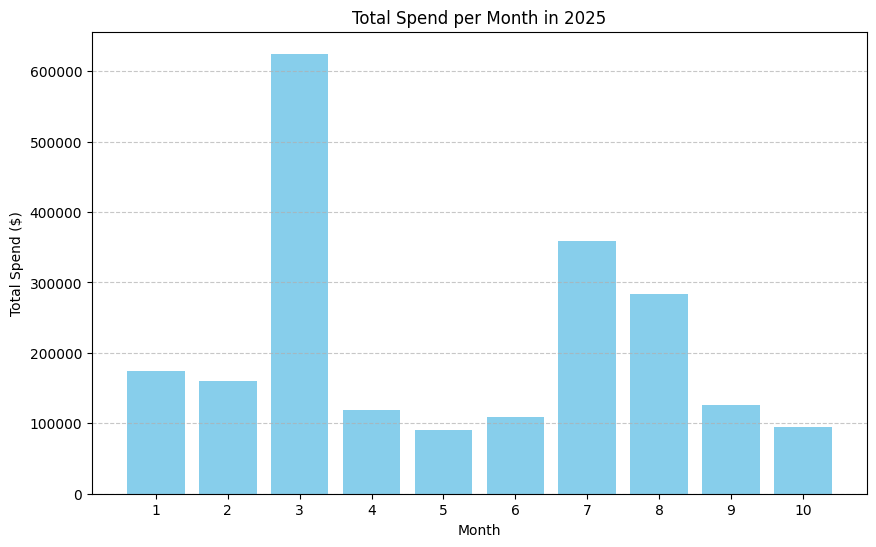

In [143]:
monthly_spend_2025 = (
    data_2025.groupby('Month')['Total Order spend']
    .sum()
    .reset_index()
)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(monthly_spend_2025['Month'], monthly_spend_2025['Total Order spend'], color='skyblue')
plt.xticks(monthly_spend_2025['Month'])
plt.xlabel('Month')
plt.ylabel('Total Spend ($)')
plt.title('Total Spend per Month in 2025')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [212]:
march_data = c_materialexpense[c_materialexpense['Month'] == 3]

# Aggregate total spend per ItemNumber
march_item_summary = (
    march_data.groupby(['ItemNumber', 'ItemDescription'])
    .agg(
        Total_Spend=('Total Order spend', 'sum'),
        Total_Count=('ItemNumber', 'count')
        )
    .reset_index()
    .sort_values(by='Total_Spend', ascending=False)  # optional: sort by spend
)

print(march_item_summary)

       ItemNumber                          ItemDescription  Total_Spend  \
81         640816  HOOP EARRING 14/20GF 1.3MMX12MM ENDLESS      16734.0   
29         107951           TWIST WIRE 14/20GF 16GA (.051)      15931.0   
1          100290                     STRIP SS .013 X 3/16      13062.0   
106        689307          JUMP RING SS 2.4 MM ID 24GA RND      11801.0   
3          100318                  RND WIRE SS 18GA (.040)      10985.0   
..            ...                                      ...          ...   
75         633061     CLASP 14/20GF 5.5MM SPRING RING OPEN        345.0   
131        924527     TAG 14/20GF 9.5MM 20GA 1.3MM HL SOFT        162.0   
112        700519     BOOK, MATT CREATIVE SETTING W/TEMPLT         53.0   
127        899961                 MONTANA SAPPH CAB RD 2MM         22.0   
42   344-1125Main               SS Chain Round Cable 1.2mm         14.0   

     Total_Count  
81             2  
29             2  
1              3  
106            2  
3   

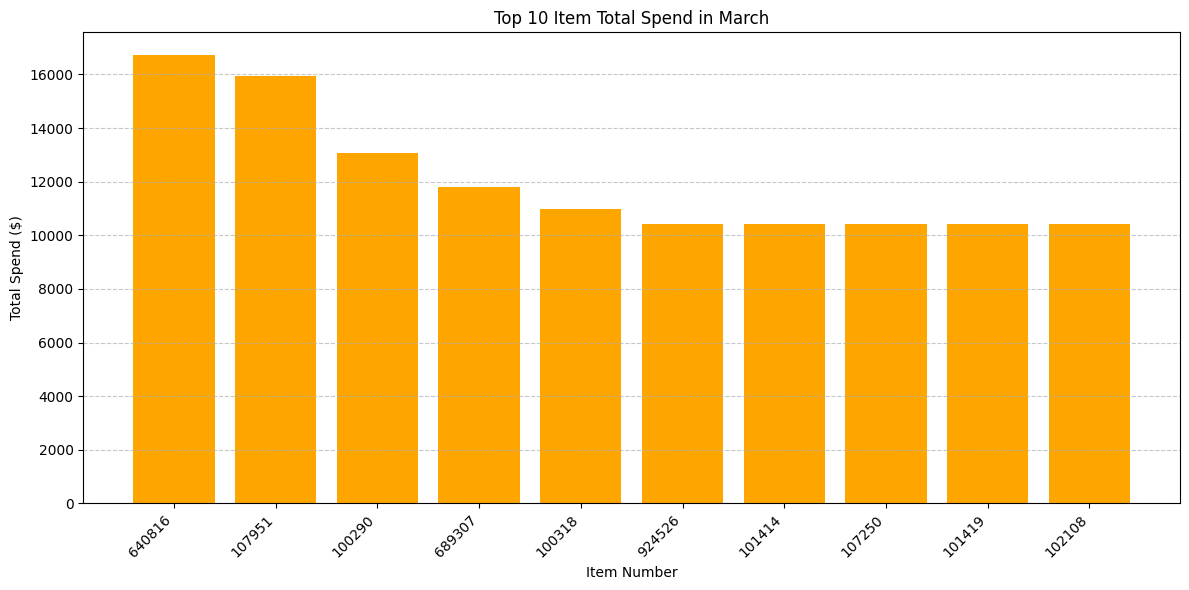

In [200]:
top_items_03_2025 = march_item_summary.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_items_03_2025['ItemNumber'].astype(str), top_items_03_2025['Total_Spend'], color='orange')
plt.xticks(rotation=45, ha='right')  # rotate x-axis labels for readability
plt.xlabel('Item Number')
plt.ylabel('Total Spend ($)')
plt.title('Top 10 Item Total Spend in March')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [155]:
# Filter rows for year 2024
data_2024 = c_materialexpense[c_materialexpense['Year'] == 2024]

# Group by Month and ItemNumber for 2024 only
monthly_item_summary_2024 = (
    data_2024.groupby(['Year', 'Month', 'ItemNumber', 'ItemDescription'])
    .agg(Total_Spend=('Total Order spend', 'sum'))
    .reset_index()
    .sort_values(by=['Month', 'Total_Spend'], ascending=[True, False])
)

print(monthly_item_summary_2024)

       Year  Month ItemNumber                           ItemDescription  \
8    2024.0    1.0     924865              JUMP RING 14KY 2.8MM ID 22GA   
9    2024.0    1.0     924866          JUMP RING 14KY 3.2MM ID 22GA RND   
3    2024.0    1.0     677314            COMP 14/20GF 12.5x11.9MM HEART   
4    2024.0    1.0     698262        TAG SS 10.6X10.3MM 24GA HEART W/HL   
1    2024.0    1.0     640829       CLASP 14/20GF TUBE 3-STRAND LAYERED   
..      ...    ...        ...                                       ...   
378  2024.0   12.0    633615B         CHAIN 14/20GF 3MM LONG & SHORT FT   
389  2024.0   12.0    683999B            CHAIN SS 5.5MM CROSS LINK FOOT   
346  2024.0   12.0     102108              PATTERN WIRE SS .118" x 050"   
416  2024.0   12.0      PER 1               CLASP 14/20GF LOBSTER 8.4MM   
355  2024.0   12.0     330031  RIO VARIABLE SPD POLISHING LATHE, 5/16 S   

     Total_Spend  
8          328.0  
9          328.0  
3          184.0  
4          184.0  
1   

In [278]:
monthly_spend_2024 = (
    data_2024.groupby('Month')['Total Order spend']
    .sum()
    .reset_index()
)

# Plot bar chart
# plt.figure(figsize=(10, 6))
# plt.bar(monthly_spend_2024['Month'], monthly_spend_2024['Total Order spend'], color='skyblue')
# plt.xticks(monthly_spend_2024['Month'])
# plt.xlabel('Month')
# plt.ylabel('Total Spend ($)')
# plt.title('Total Spend per Month in 2024')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

# Using Plotly to make the same visual

# Rename Month Number to Month Name
monthly_spend_2024.dtypes

# Convert 'Month' to int
monthly_spend_2024['Month'] = monthly_spend_2024['Month'].astype(int)

monthly_spend_2024['Month'] = monthly_spend_2024['Month'].apply(lambda x: datetime.date(1900, x, 1).strftime('%B'))
monthly_spend_2024.head()

# Plot Bar Chart

fig = px.bar(monthly_spend_2024, x='Month', y='Total Order spend', title='Total Spend per Month in 2024')
fig.update_layout(xaxis_title='Month', yaxis_title='Total Order ($)', height=800)
fig.update_traces(
    textposition='outside',       # 'inside' keeps labels within the bars
    texttemplate='%{y:.0f}',      # format the text to show 2 decimal places
    textfont_size=10,             # adjust font size if needed
)
fig.update_xaxes(tickangle=90)
fig.show()


In [ ]:
# Create Grouped Bar Chart for All Years

# Filter data for 2024
data_2024 = c_materialexpense[c_materialexpense['Year'] == 2024]

# Aggregate total spend per month
import plotly.express as px


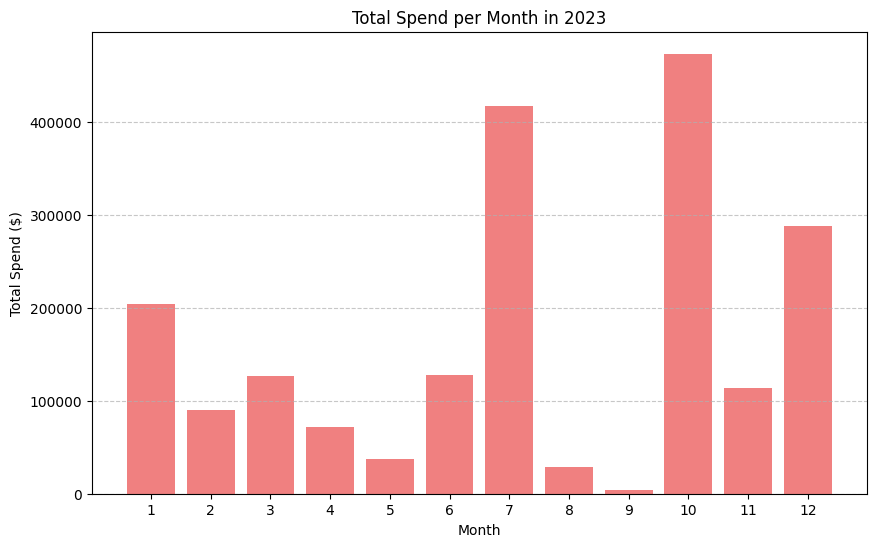

In [161]:
# Filter data for 2023
data_2023 = c_materialexpense[c_materialexpense['Year'] == 2023]

# Aggregate total spend per month
monthly_spend_2023 = (
    data_2023.groupby('Month')['Total Order spend']
    .sum()
    .reset_index()
)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(monthly_spend_2023['Month'], monthly_spend_2023['Total Order spend'], color='lightcoral')
plt.xticks(monthly_spend_2023['Month'])
plt.xlabel('Month')
plt.ylabel('Total Spend ($)')
plt.title('Total Spend per Month in 2023')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

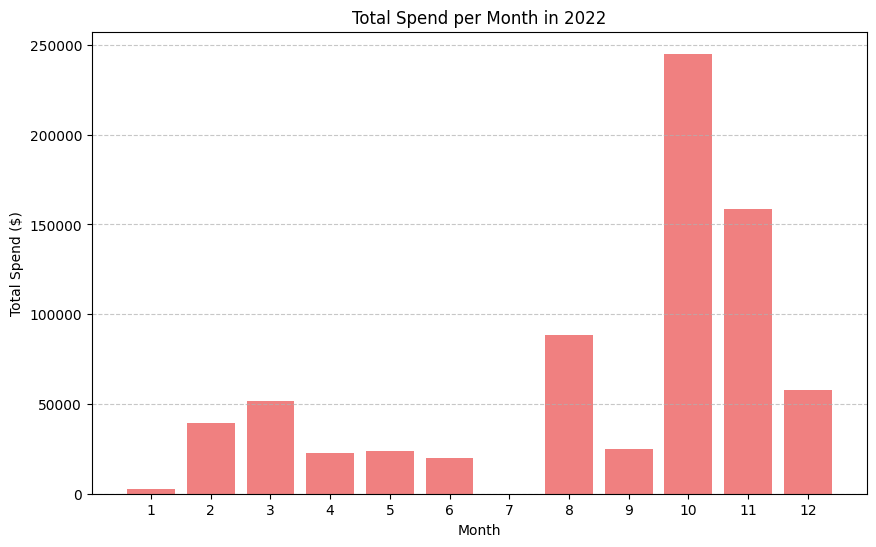

In [164]:
# Filter data for 2023
data_2022 = c_materialexpense[c_materialexpense['Year'] == 2022]

# Aggregate total spend per month
monthly_spend_2022 = (
    data_2022.groupby('Month')['Total Order spend']
    .sum()
    .reset_index()
)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(monthly_spend_2022['Month'], monthly_spend_2022['Total Order spend'], color='lightcoral')
plt.xticks(monthly_spend_2022['Month'])
plt.xlabel('Month')
plt.ylabel('Total Spend ($)')
plt.title('Total Spend per Month in 2022')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

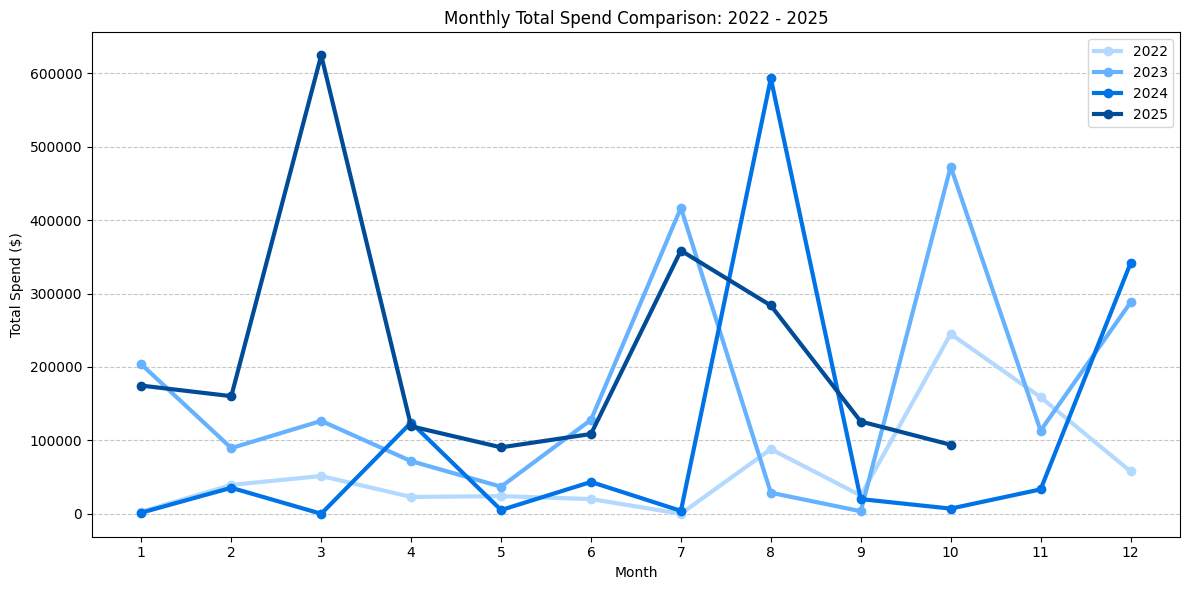

In [308]:
monthly_spend_2022 = c_materialexpense[c_materialexpense['Year'] == 2022].groupby('Month')['Total Order spend'].sum()
monthly_spend_2023 = c_materialexpense[c_materialexpense['Year'] == 2023].groupby('Month')['Total Order spend'].sum()
monthly_spend_2024 = c_materialexpense[c_materialexpense['Year'] == 2024].groupby('Month')['Total Order spend'].sum()
monthly_spend_2025 = c_materialexpense[c_materialexpense['Year'] == 2025].groupby('Month')['Total Order spend'].sum()

colors = ['#B3D9FF', '#66B2FF', '#0073E6', '#004C99']
# Plot the lines
plt.figure(figsize=(12, 6))
plt.plot(monthly_spend_2022.index, monthly_spend_2022.values, marker='o', label='2022', color=colors[0], linewidth=3)
plt.plot(monthly_spend_2023.index, monthly_spend_2023.values, marker='o', label='2023', color=colors[1], linewidth=3)
plt.plot(monthly_spend_2024.index, monthly_spend_2024.values, marker='o', label='2024', color=colors[2], linewidth=3)
plt.plot(monthly_spend_2025.index, monthly_spend_2025.values, marker='o', label='2025', color=colors[3], linewidth=3)

# Labels and title
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Total Spend ($)')
plt.title('Monthly Total Spend Comparison: 2022 - 2025')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Redo Using Plotly

# Plot Bar Chart

import plotly.express as px
import pandas as pd

# Combine all years into a single DataFrame
monthly_spend_all = pd.concat([
    c_materialexpense[c_materialexpense['Year'] == 2022].groupby('Month')['Total Order spend'].sum().rename('2022'),
    c_materialexpense[c_materialexpense['Year'] == 2023].groupby('Month')['Total Order spend'].sum().rename('2023'),
    c_materialexpense[c_materialexpense['Year'] == 2024].groupby('Month')['Total Order spend'].sum().rename('2024'),
    c_materialexpense[c_materialexpense['Year'] == 2025].groupby('Month')['Total Order spend'].sum().rename('2025'),
], axis=1).reset_index()

# Melt for Plotly Express
monthly_spend_melted = monthly_spend_all.melt(
    id_vars='Month',
    var_name='Year',
    value_name='Total Spend'
)

# Define your custom colors
color_map = {
    '2022': '#B3D9FF',
    '2023': '#66B2FF',
    '2024': '#0073E6',
    '2025': '#004C99'
}

# Create interactive Plotly line chart
fig = px.line(
    monthly_spend_melted,
    x='Month',
    y='Total Spend',
    color='Year',
    color_discrete_map=color_map,
    markers=True,
    title='Monthly Total Spend Comparison: 2022–2025'
)

# Customize layout and hover
fig.update_layout(
    xaxis=dict(tickmode='linear', tick0=1, dtick=1, title='Month'),
    yaxis_title='Total Spend ($)',
    legend_title_text='Year',
    template='simple_white',
    paper_bgcolor='#EAEAEA',   # <— add here
    plot_bgcolor='#EAEAEA',     # <— add here
    width=800
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=8),
    hovertemplate='Year: %{color}<br>Month: %{x}<br>Total Spend: $%{y:,.0f}<extra></extra>', 
)

fig.show()


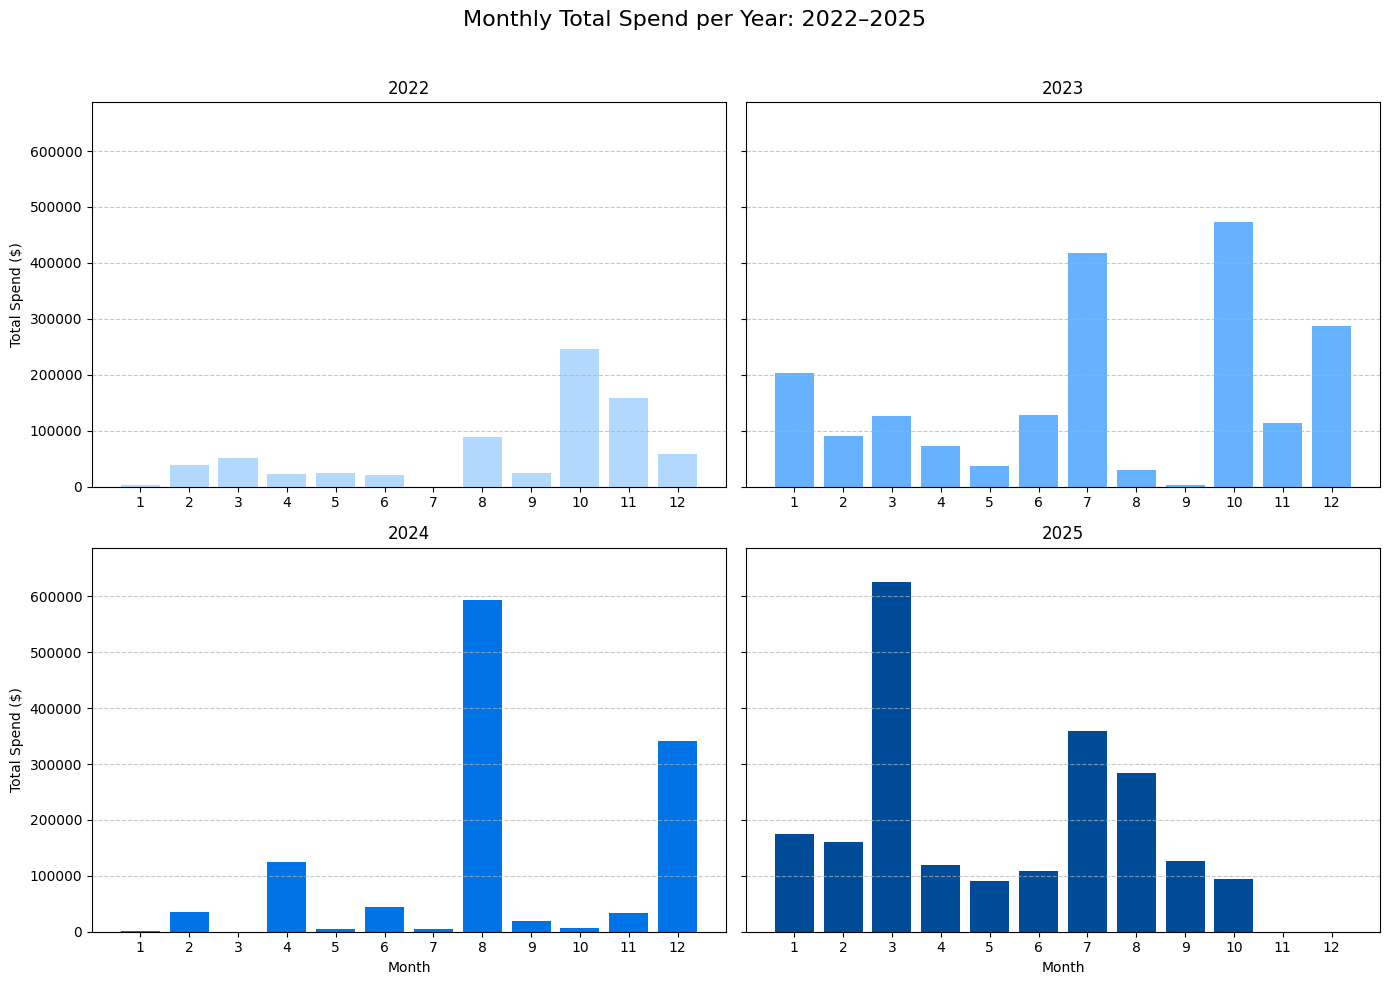

In [197]:
# Prepare monthly total spend for each year
months = range(1, 13)
spend_2022 = c_materialexpense[c_materialexpense['Year'] == 2022].groupby('Month')['Total Order spend'].sum().reindex(months, fill_value=0)
spend_2023 = c_materialexpense[c_materialexpense['Year'] == 2023].groupby('Month')['Total Order spend'].sum().reindex(months, fill_value=0)
spend_2024 = c_materialexpense[c_materialexpense['Year'] == 2024].groupby('Month')['Total Order spend'].sum().reindex(months, fill_value=0)
spend_2025 = c_materialexpense[c_materialexpense['Year'] == 2025].groupby('Month')['Total Order spend'].sum().reindex(months, fill_value=0)

# Find the max total spend across all years for consistent y-axis
max_spend = max(spend_2022.max(), spend_2023.max(), spend_2024.max(), spend_2025.max())

# Create 2x2 subplots with shared y-axis
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
fig.suptitle('Monthly Total Spend per Year: 2022–2025', fontsize=16)

# Plot for each year
axes[0, 0].bar(months, spend_2022.values, color='#B3D9FF')
axes[0, 0].set_title('2022')
axes[0, 0].set_xticks(months)
axes[0, 0].set_ylabel('Total Spend ($)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 0].set_ylim(0, max_spend*1.1)

axes[0, 1].bar(months, spend_2023.values, color='#66B2FF')
axes[0, 1].set_title('2023')
axes[0, 1].set_xticks(months)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 1].set_ylim(0, max_spend*1.1)

axes[1, 0].bar(months, spend_2024.values, color='#0073E6')
axes[1, 0].set_title('2024')
axes[1, 0].set_xticks(months)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Spend ($)')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 0].set_ylim(0, max_spend*1.1)

axes[1, 1].bar(months, spend_2025.values, color='#004C99')
axes[1, 1].set_title('2025')
axes[1, 1].set_xticks(months)
axes[1, 1].set_xlabel('Month')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 1].set_ylim(0, max_spend*1.1)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=65165b0f-3ecd-4b4c-bb31-a66c4e6fcba5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>